# Celeba

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import lightning as L
import torch
import os, sys
import numpy as np
import pickle
sys.path.append("/home/younsuk/causal_cbm/")
import networkx as nx
from utils import *
torch.manual_seed(0)
np.random.seed(0)



In [2]:
task_name = "Mouth_Slightly_Open"

c_file = "/home/younsuk/.cache/c2bm/celeba/preprocessed_dataset_1.pkl"
c = pickle.load(open(c_file, "rb"))
train = c.data["train"]
val = c.data["val"]
test = c.data["test"]


/opt/anaconda3/envs/younsuk_cbm/lib/python3.11/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


## gragh check

/tmp/ipykernel_2381006/1732816292.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


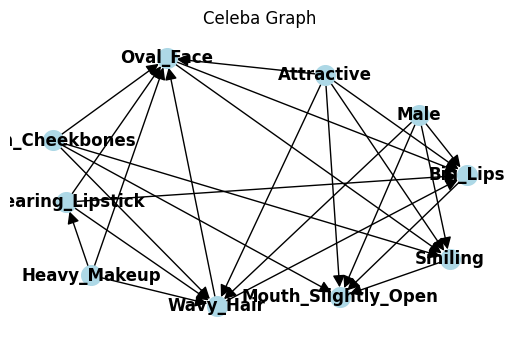

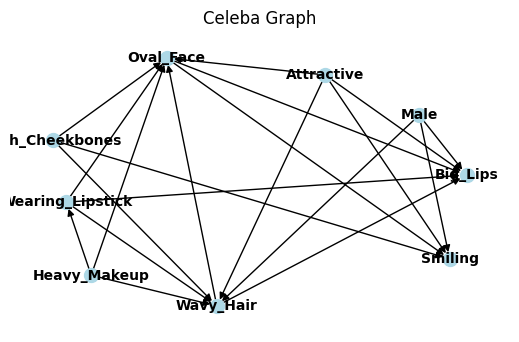

In [5]:
adj_pd = pickle.load(open("/home/younsuk/.cache/c2bm/celeba/graph.pkl", "rb"))
adj_org = nx.from_pandas_adjacency(adj_pd, create_using=nx.DiGraph)
plt.figure(figsize=(5, 3))
pos = nx.spring_layout(adj_org, k=3, seed=42)  # Increase k for more spread
nx.draw(adj_org, pos=pos, with_labels=True, node_color='lightblue', node_size=200, font_size=12, font_weight='bold', arrowsize=18)
plt.title('Celeba Graph')
plt.tight_layout()
plt.show()

#remove task_name from adj_pd ; column and row
adj_pd = adj_pd.drop(task_name, axis=0).drop(task_name, axis=1)

graph_celeba = nx.from_pandas_adjacency(adj_pd, create_using=nx.DiGraph)

# Plot the graph
plt.figure(figsize=(5, 3))
nx.draw(graph_celeba,pos = pos, with_labels=True, node_color='lightblue', node_size=100, font_size=10, font_weight='bold')
plt.title('Celeba Graph')
plt.show()

In [6]:
order = adj_pd.index.tolist()
topo_order = list(nx.topological_sort(graph_celeba))
print("Topological order of nodes:", topo_order)
print("Before topological order:", order)

topo_order_idx = [order.index(node) for node in topo_order]

# rearrange adj_pd with topo_order
adj_pd_topo = adj_pd.loc[topo_order, topo_order]
print(adj_pd_topo)
print(adj_pd)

adj_cnf = adj_pd_topo.to_numpy(dtype=np.int8).transpose(1,0)
adj_cnf += np.eye(adj_cnf.shape[0], dtype=np.int8)
adj_cnf



Topological order of nodes: ['Attractive', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Wearing_Lipstick', 'Wavy_Hair', 'Oval_Face', 'Big_Lips', 'Smiling']
Before topological order: ['Attractive', 'Big_Lips', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Oval_Face', 'Smiling', 'Wavy_Hair', 'Wearing_Lipstick']
                  Attractive  Heavy_Makeup  High_Cheekbones  Male  \
Attractive                 0             0                0     0   
Heavy_Makeup               0             0                0     0   
High_Cheekbones            0             0                0     0   
Male                       0             0                0     0   
Wearing_Lipstick           0             0                0     0   
Wavy_Hair                  0             0                0     0   
Oval_Face                  0             0                0     0   
Big_Lips                   0             0                0     0   
Smiling                    0             0                0     0   

 

array([[1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 1, 0, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 0, 0, 0],
       [1, 1, 1, 0, 1, 1, 1, 0, 0],
       [1, 0, 0, 1, 1, 1, 1, 1, 0],
       [1, 0, 1, 1, 0, 0, 1, 0, 1]], dtype=int8)

## CNF Learning and Inference on Sachs dataset

### Data check

In [7]:

def post_process(x, binary_dims, binary_min_values, binary_max_values, inplace=False):
    if not inplace:
        x = x.clone()
    x[..., binary_dims] = x[..., binary_dims].floor().float()
    x[..., binary_dims] = torch.clamp(x[..., binary_dims], min=binary_min_values, max=binary_max_values)

    return x

def add_noise(x):
    # Calculate the standard deviation of each column
    std = torch.std(x, dim=0).mul(100).round() / 100.0

    # Find the columns that are constant (i.e., have a standard deviation of 0)
    constant_mask = std == 0
    # # Generate a small amount of noise for each constant column
    # noise = torch.rand(x.shape[0], sum(constant_mask)) * 2.0 - 1.0
    noise = torch.randn(x.shape[0], sum(constant_mask))
    # Add the noise to the corresponding columns
    x[:, constant_mask] += noise * 0.01
    return x

In [14]:
# dataset as tensor
train_C = torch.tensor(train.c, dtype=torch.float32)
train_Y = torch.tensor(train.y, dtype=torch.float32)
print(train_C.shape, train_Y.shape)

test_C = torch.tensor(test.c, dtype=torch.float32)
test_Y = torch.tensor(test.y, dtype=torch.float32)
print(test_C.shape, test_Y.shape)

val_C = torch.tensor(val.c, dtype=torch.float32)
val_Y = torch.tensor(val.y, dtype=torch.float32)
print(val_C.shape, val_Y.shape)


##preprocessing

#column-wise rearrange as topological order (topo_order_idx)
train_C_topo = train_C[:,topo_order_idx]
test_C_topo = test_C[:,topo_order_idx]
val_C_topo = val_C[:,topo_order_idx]

print(train_C_topo.shape, test_C_topo.shape, val_C_topo.shape)


# binary idx
binary_dims = list(range(0, train_C.shape[1]))
binary_min_values = train_C[:, binary_dims].min(dim=0)[0]
binary_max_values = train_C[:, binary_dims].max(dim=0)[0]

#dequantization
train_C_topo_deq = train_C_topo[:, binary_dims] + torch.rand_like(train_C_topo[:, binary_dims])
test_C_topo_deq = test_C_topo[:, binary_dims] + torch.rand_like(test_C_topo[:, binary_dims])
val_C_topo_deq = val_C_topo[:, binary_dims] + torch.rand_like(val_C_topo[:, binary_dims])
print(train_C_topo_deq.shape, test_C_topo_deq.shape, val_C_topo_deq.shape)

def create_df(tensors_dict):
    df_list = []
    for i, (k, x) in enumerate(tensors_dict.items()):
        df = pd.DataFrame(x.numpy(), columns=[f'$x_{j}$' for j in range(x.shape[1])])
        df['name'] = k
        df_list.append(df)

    df = pd.concat(df_list)
    return df


def plot_data(tensors_dict, mode = "kde"):
    df = create_df(tensors_dict)
    g = sns.PairGrid(df, diag_sharey=False, hue='name')
    g.map_upper(sns.scatterplot, s=15, alpha=0.5)
    if mode == "kde":
        g.map_lower(sns.kdeplot, common_norm=False)
        g.map_diag(sns.kdeplot, lw=2, common_norm=False)
    elif mode == "hist":
        g.map_lower(sns.histplot, bins=20)
        g.map_diag(sns.histplot, bins=20)
    g.add_legend()
    plt.show()



# plot_data({'Data': test_C_topo_deq}, "kde")

torch.Size([162770, 9]) torch.Size([162770, 1])
torch.Size([19962, 9]) torch.Size([19962, 1])
torch.Size([19867, 9]) torch.Size([19867, 1])
torch.Size([162770, 9]) torch.Size([19962, 9]) torch.Size([19867, 9])
torch.Size([162770, 9]) torch.Size([19962, 9]) torch.Size([19867, 9])


/tmp/ipykernel_2381006/549161516.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_C = torch.tensor(train.c, dtype=torch.float32)
/tmp/ipykernel_2381006/549161516.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_Y = torch.tensor(train.y, dtype=torch.float32)
/tmp/ipykernel_2381006/549161516.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_C = torch.tensor(test.c, dtype=torch.float32)
/tmp/ipykernel_2381006/549161516.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().d

### Training

In [16]:

from torch.utils.data import DataLoader, TensorDataset
# Create the dataloaders
batch_size = 1024
train_dataset = TensorDataset(train_C_topo_deq)
train_loader = DataLoader(train_dataset, batch_size, shuffle=True)

test_dataset = TensorDataset(test_C_topo_deq)
test_loader = DataLoader(test_dataset, batch_size=test_C_topo_deq.shape[0])

In [17]:
from causalflows.flows import CausalMAF

features = 9
context = 0
flow = CausalMAF(features, context, adjacency=adj_cnf)




# init the autoencoder
model = LitFlow(flow)

logger = MyLogger()
trainer = L.Trainer(
    max_epochs=300, logger=logger, enable_checkpointing=False, log_every_n_steps=len(train_loader)
)
trainer.fit(model=model, train_dataloaders=train_loader)

Trainer will use only 1 of 3 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=3)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA RTX A5000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]

  | Name | Type      | Params | Mode  | FLOPs
---------------------------------------------------
0 | flow | CausalMAF | 6.0 K  | train | 0    
---------------------------------------------------
6.0 K     Trainable params
0         Non

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=300` reached.


save model

In [18]:
save_file = "cnf_bundle_celeba.pt"
torch.save({
    "state_dict": model.flow.state_dict(),
    "features": features,
    "context": context,
    "adjacency": adj_cnf,
    "topo_order_idx": topo_order_idx,
    "original_order": order,
    "topological_order": topo_order,
    "binary_dims": binary_dims,
    "binary_min_values": binary_min_values,
    "binary_max_values": binary_max_values,
}, save_file)

load model (optional)

In [19]:
save_file = "cnf_bundle_celeba.pt"
bundle = torch.load(save_file, map_location="cpu")
flow_loaded = CausalMAF(bundle["features"], bundle["context"], adjacency=bundle["adjacency"])
flow_loaded.load_state_dict(bundle["state_dict"])
flow_loaded.eval()

/tmp/ipykernel_2381006/2348717766.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  bundle = torch.load(save_file, map_location="cpu")


CausalMAF(
  (transform): MaskedAutoregressiveTransform(
    (base): MonotonicAffineTransform()
    (passes): 5
    (hyper): MaskedMLP(
      (0): MaskedLinear(in_features=9, out_features=64, bias=True)
      (1): ReLU()
      (2): MaskedLinear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): MaskedLinear(in_features=64, out_features=18, bias=True)
    )
  )
  (base): UnconditionalDistribution(DiagNormal(loc: torch.Size([9]), scale: torch.Size([9])))
)

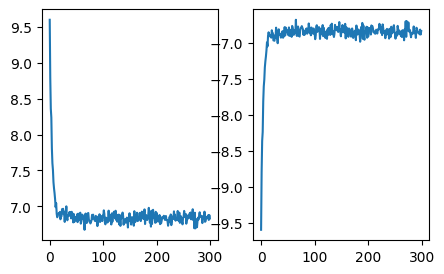

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(5, 3))
sns.lineplot(x=logger.values['epoch'], y=logger.values['train_loss'], ax=axs[0])
sns.lineplot(x=logger.values['epoch'], y=logger.values['log_prob'], ax=axs[1])
plt.show()

### Inference

observational

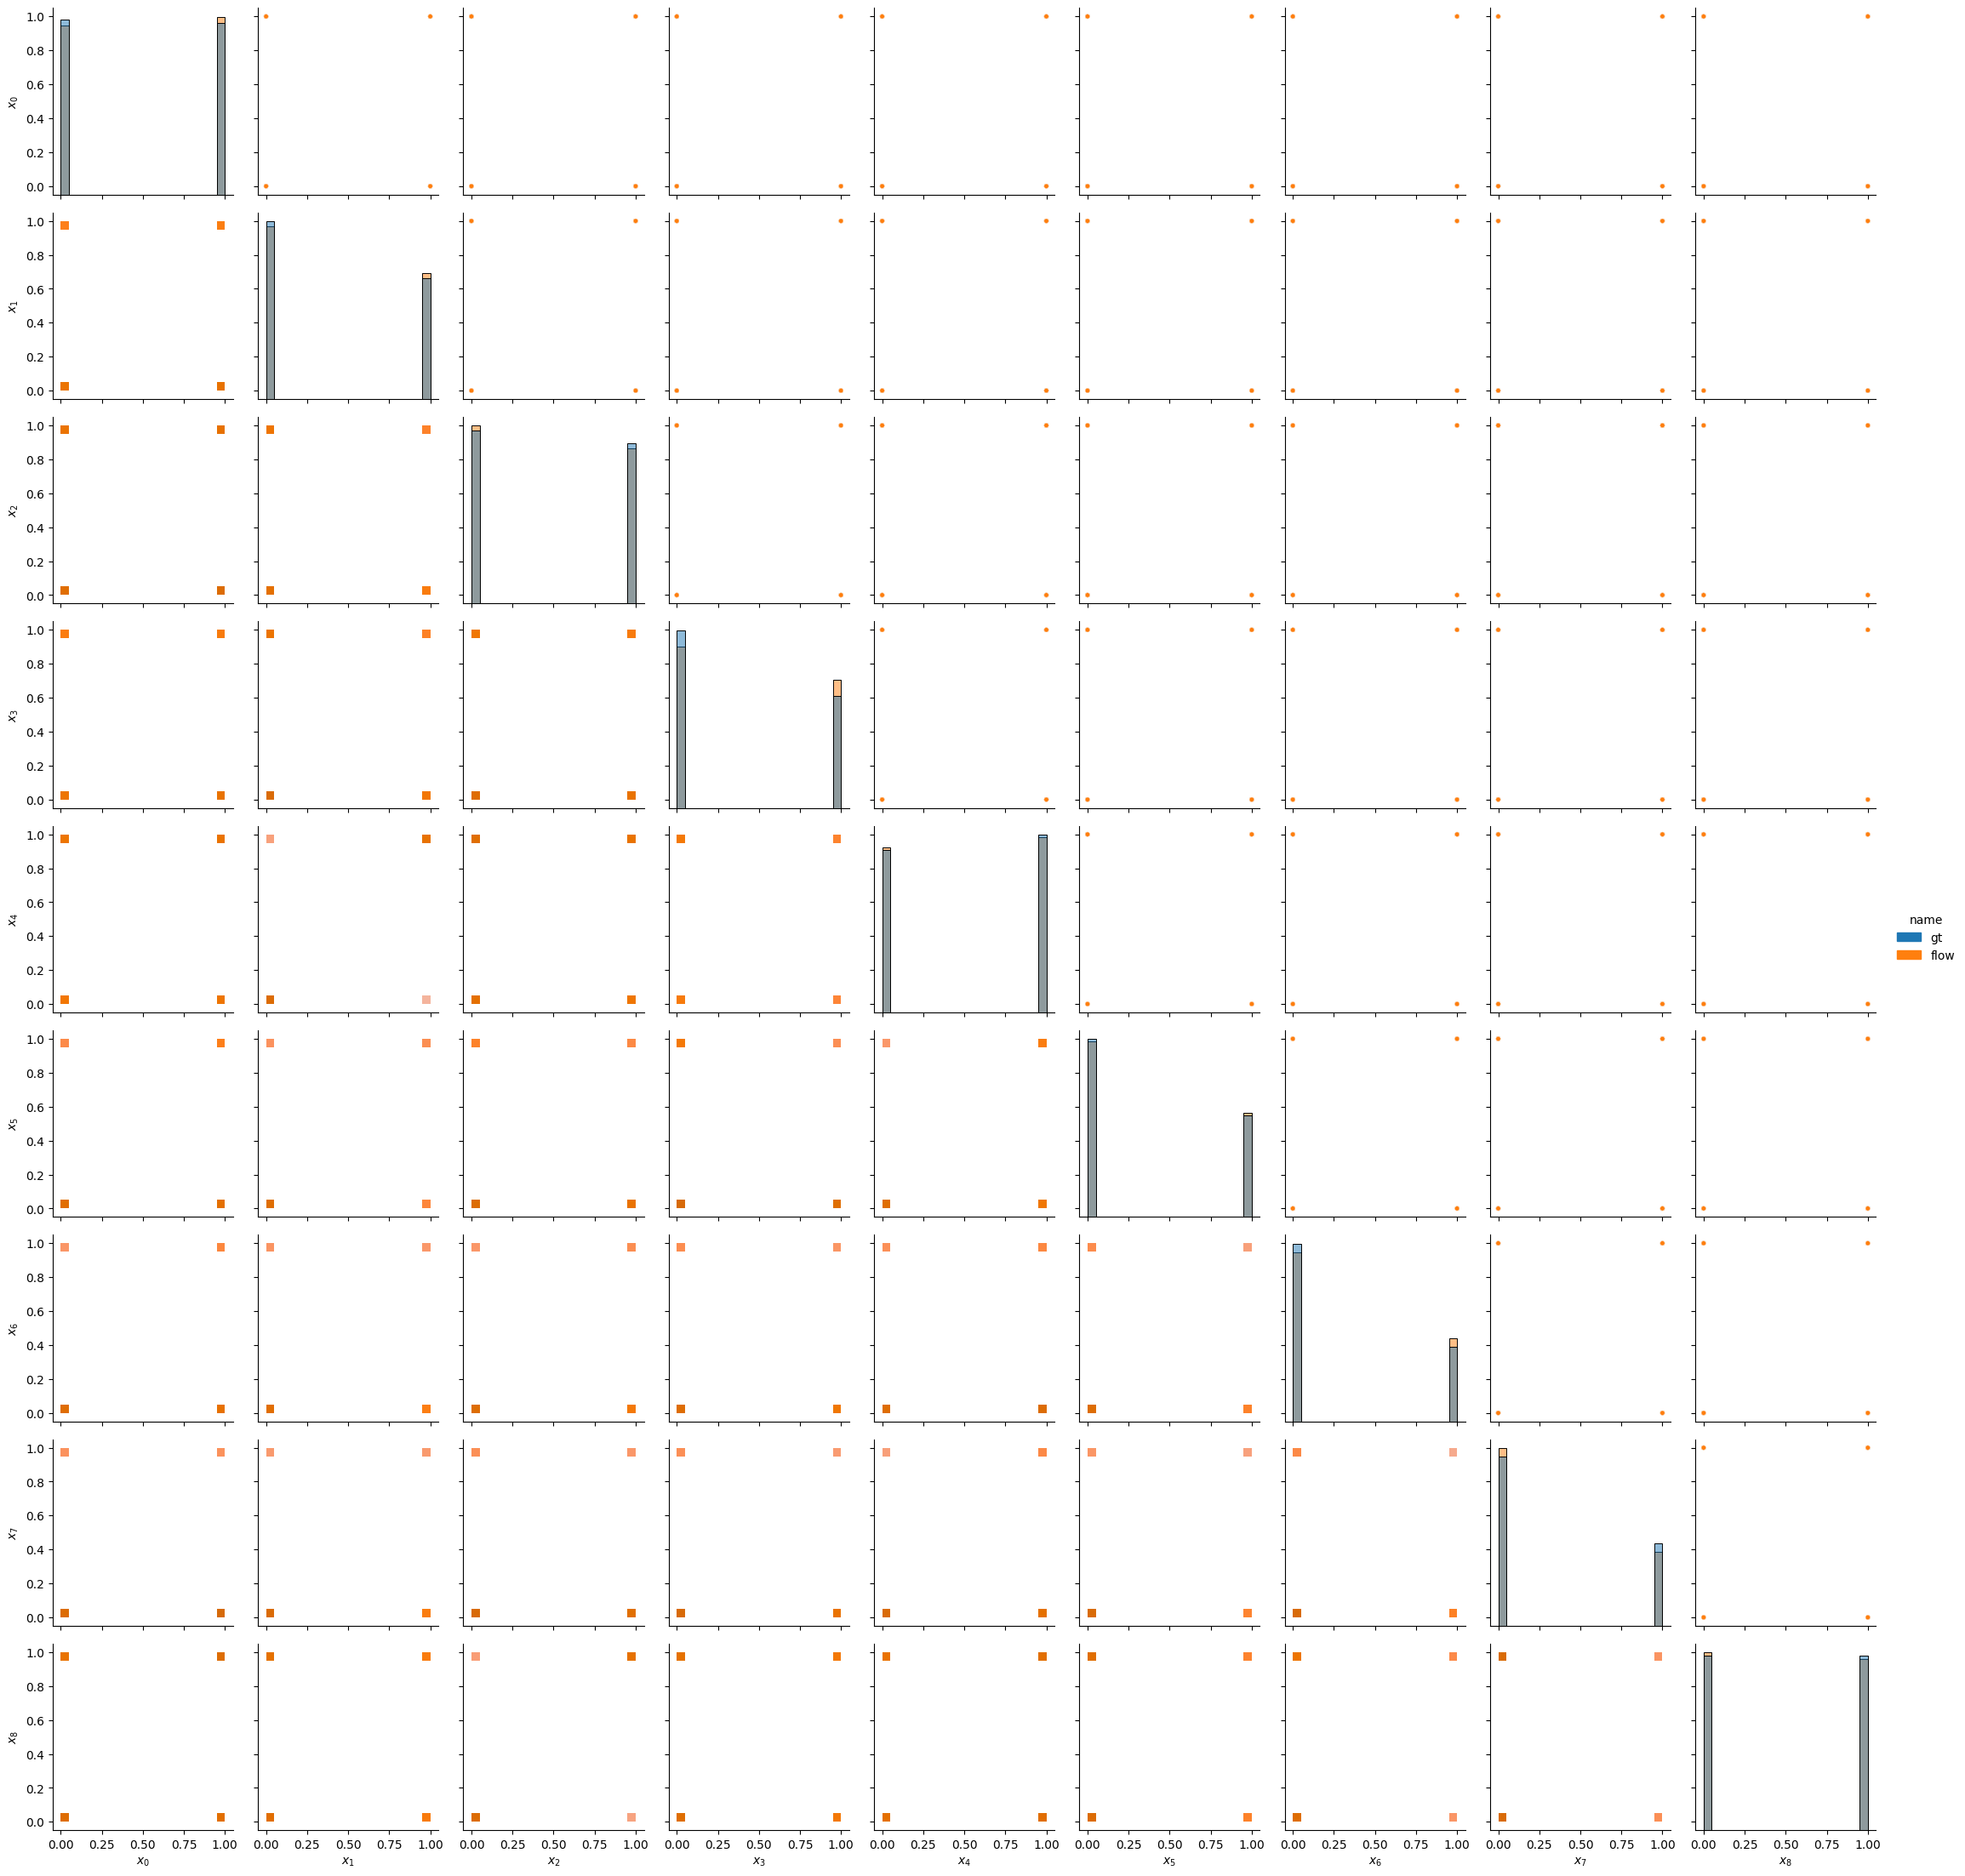

In [21]:
# observational
gt_obs = post_process(test_C_topo_deq, binary_dims, binary_min_values, binary_max_values)
obs_data =flow().sample([test_C_topo_deq.shape[0]])
obs_data = post_process(obs_data, binary_dims, binary_min_values, binary_max_values)

plot_data({'gt': gt_obs, 'flow': obs_data}, "hist")


interventional

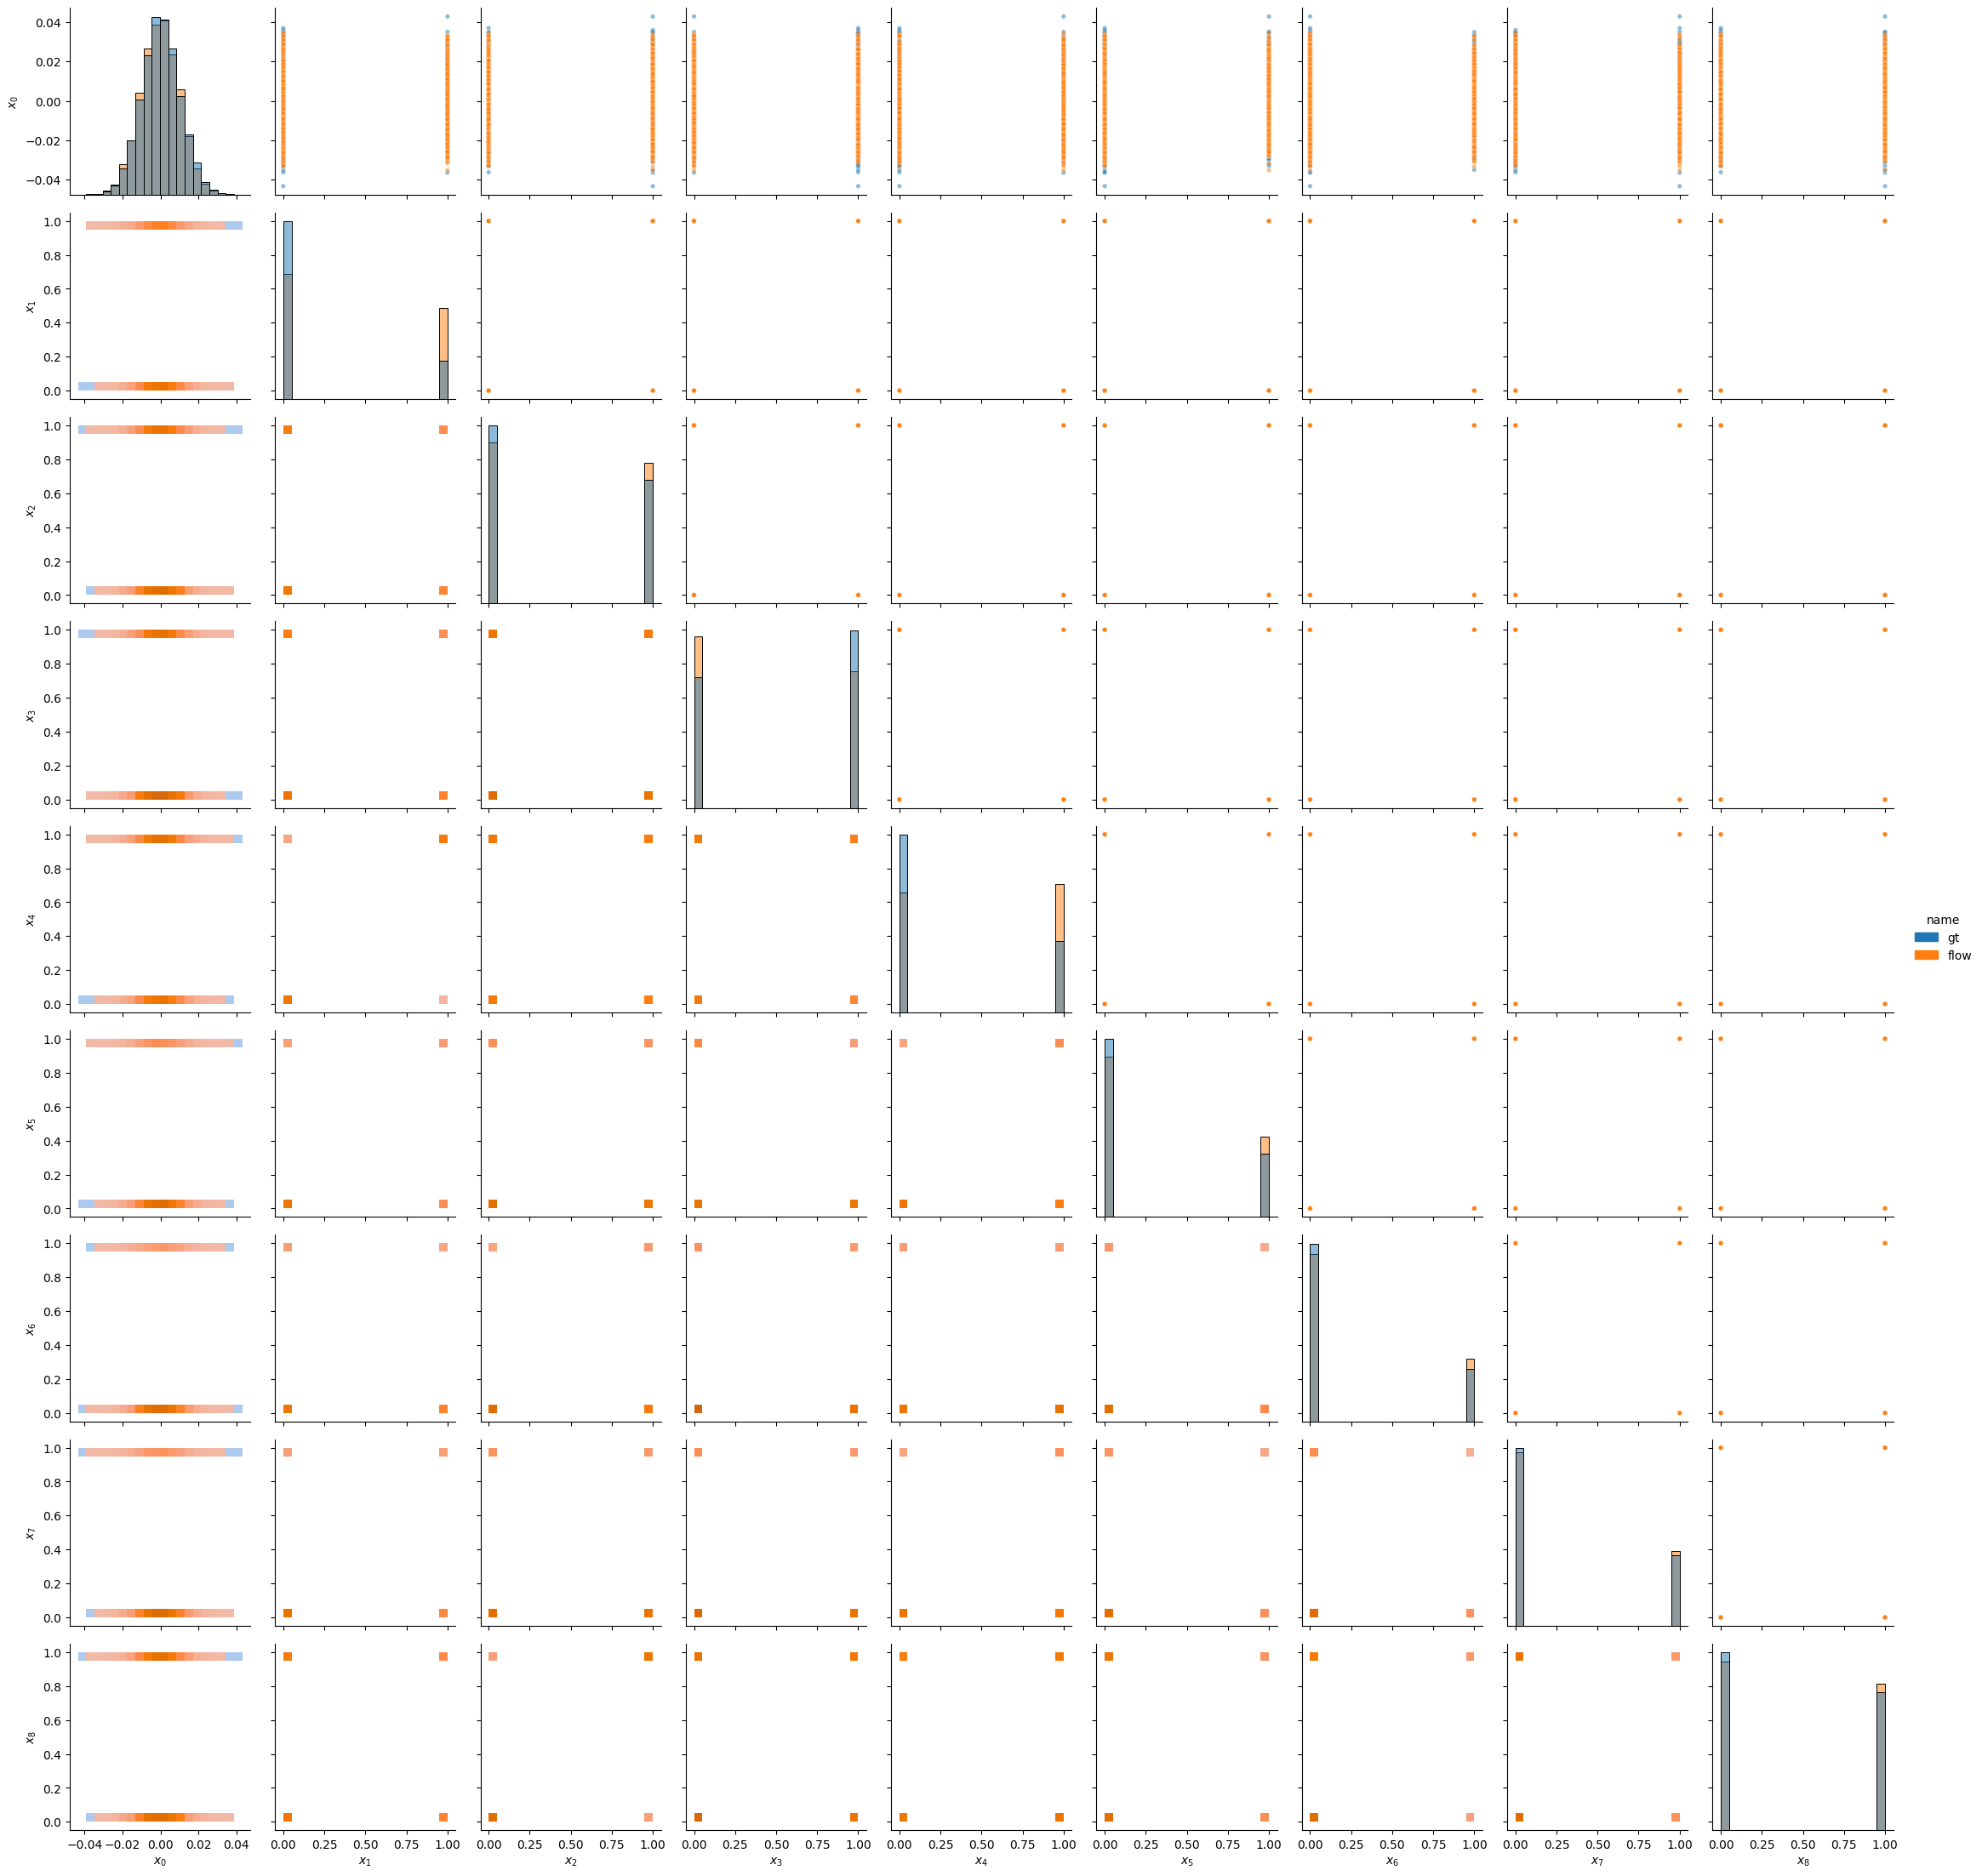

In [22]:
# intervention
index, value = 0, 0

#"simple" ground truth : conditional on root is same as intervention on root
mask = test_C_topo_deq[..., index].floor() == int(value)
int_gt = test_C_topo_deq[mask, :]
int_gt = add_noise(post_process(int_gt, binary_dims, binary_min_values, binary_max_values))

#generate intervention data
int_data = flow().sample_interventional(index=0, value=0+torch.rand(1), sample_shape=(int_gt.shape[0],))
int_data = add_noise(post_process(int_data, binary_dims, binary_min_values, binary_max_values))

#plot
plot_data({'gt': int_gt, 'flow': int_data}, "hist")


counterfactual

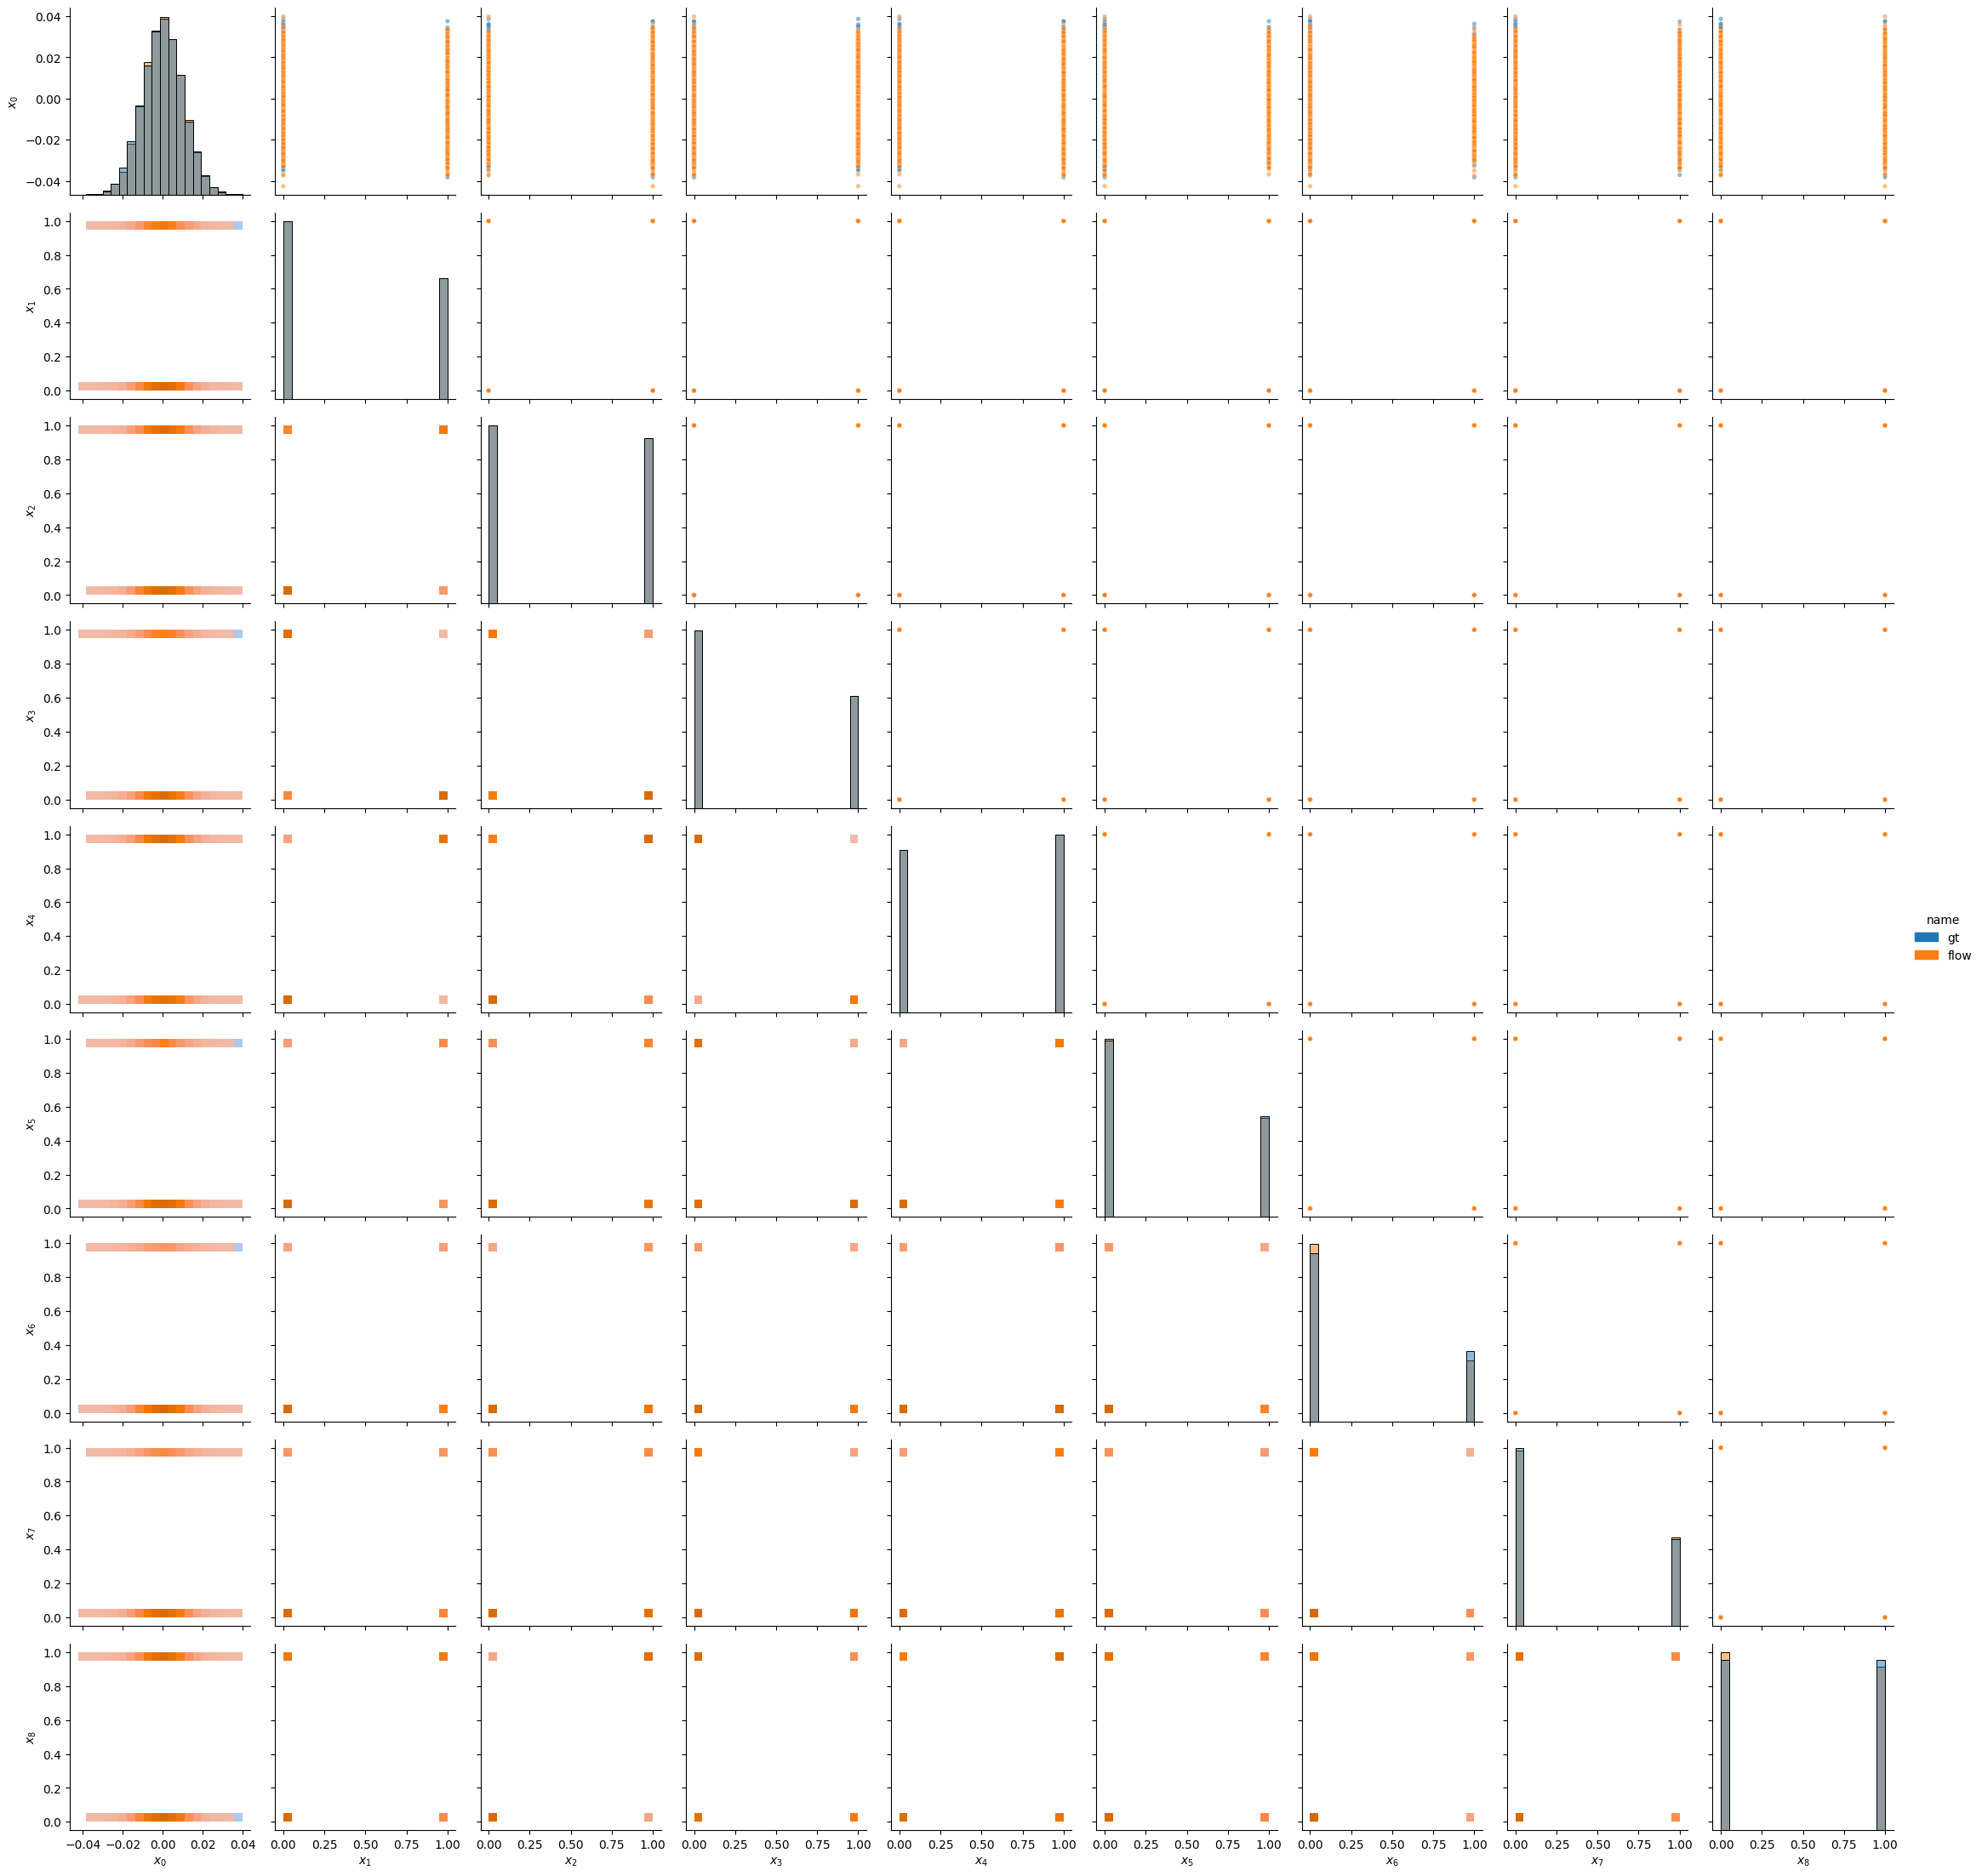

In [23]:
# intervention
index, value = 0, 0
x_cf = test_C_topo_deq.clone()


#"simple" ground truth : fixing value on root node of given factual data
cf_gt = x_cf.clone()
cf_gt[..., index] = value
cf_gt = add_noise(post_process(cf_gt, binary_dims, binary_min_values, binary_max_values))

#generate intervention data
cf_data = flow().compute_counterfactual(x_cf, index=0, value=0+torch.rand(1)).detach().cpu()
cf_data = add_noise(post_process(cf_data, binary_dims, binary_min_values, binary_max_values))

#plot
plot_data({'gt': cf_gt, 'flow': cf_data}, "hist")

## CBM, Causal Analysis.
* First, train vanilla, CBM or C2BM
* Then, extract 'predicted/inferenced' concept labels, corresponding to test dataset samples
* Analyzing distributional gaps between latent representations of true concepts and those derived from predicted concepts. (for 'Leakge analysis')
* Generate counterfactual concept predictions when given factual inputs, and apply them to (Causal)CBM as 'concept interventions' on test time

#### Leakage Analysis

In [ ]:
'''
<CBM>
'''
run_id, incomplete_concepts = "2025-12-11/17-12-26_cbm_mlp_celeba", None


In [ ]:
save_file = "cnf_bundle_celeba.pt"
from causalflows.flows import CausalMAF
bundle = torch.load(save_file, map_location="cpu")
flow_loaded = CausalMAF(bundle["features"], bundle["context"], adjacency=bundle["adjacency"])
flow_loaded.load_state_dict(bundle["state_dict"])
flow_loaded.eval()

In [ ]:
topo_order_idx = bundle["topo_order_idx"]
original_order = bundle["original_order"]
topological_order = bundle["topological_order"]
binary_dims = bundle["binary_dims"]
binary_min_values = bundle["binary_min_values"]
binary_max_values = bundle["binary_max_values"]
print(original_order)
print(topological_order)

extract ground truth concept labels and align to topological_order : complete concept set

In [ ]:

c_file = "/home/younsuk/.cache/c2bm/celeba/preprocessed_dataset_1.pkl"
c = pickle.load(open(c_file, "rb"))
c_tensor = c.data["test"].c

c_tensor_topo = c_tensor[:, topo_order_idx]
c_tensor_topo_deq = c_tensor_topo.clone()
# 고정된 시드로 dequantization하여 재현 가능하게 만듦
torch.manual_seed(42)
c_tensor_topo_deq[:, binary_dims] = c_tensor_topo_deq[:, binary_dims] + torch.rand_like(
    c_tensor_topo_deq[:, binary_dims]
)
y_true = c.data["test"].y.squeeze()

extract predicted concept labels from CBM

In [ ]:
import pickle

incomplete_idx = [topological_order.index(name) for name in incomplete_concepts] if incomplete_concepts else None

# predicted concept labels' accuracy
acc_file = f"../outputs/multirun/{run_id}/0/results/c_accuracy.pkl"
acc = pickle.load(open(acc_file, "rb"))
print(acc)

y_acc_file = f"../outputs/multirun/{run_id}/0/results/y_accuracy.pkl"
y_acc = pickle.load(open(y_acc_file, "rb"))["_baseline"]
print(y_acc)

# extracted predicted concept labels
c_hat_file = f"../outputs/multirun/{run_id}/0/results/c_hat_all.pkl"
c_hat = pickle.load(open(c_hat_file, "rb"))

# helper to coerce to 1D float tensor column
def _to_column_tensor(x):
    t = torch.as_tensor(x)
    if t.ndim == 2 and t.shape[1] == 1:
        t = t.squeeze(1)
    return t.float().view(-1, 1)



c_hat_cols = []
for i, name in enumerate(topological_order):
    if name in c_hat:
        print(f"[{name}] add predicted concept")
        c_hat_cols.append(_to_column_tensor(c_hat[name]))
    else:
        print(f"[{name}] add alternative(zero / true) concept")
        # c_hat_cols.append(zero_col_hat)
        c_hat_cols.append(c_tensor_topo[:, i].view(-1, 1))

c_hat_tensor_topo = torch.cat(c_hat_cols, dim=1)
c_hat_tensor_topo_deq = c_hat_tensor_topo.clone()
# 고정된 시드로 dequantization하여 재현 가능하게 만듦
torch.manual_seed(42)
c_hat_tensor_topo_deq[:, binary_dims] = c_hat_tensor_topo_deq[:, binary_dims] + torch.rand_like(
    c_hat_tensor_topo_deq[:, binary_dims]
)
print(c_hat_tensor_topo.shape)



Transform true/predicted concept labels to corresponding latent space

In [ ]:
#complete concepts 전용

u_topo = flow_loaded().transform(c_tensor_topo_deq).detach().cpu()
u_hat_topo = flow_loaded().transform(c_hat_tensor_topo_deq).detach().cpu()

if incomplete_concepts:
    u_topo = u_topo[:, incomplete_idx]
    u_hat_topo = u_hat_topo[:, incomplete_idx]


In [ ]:
# plot_data({'u_gt': u_topo, 'u_hat': u_hat_topo}, "kde", col_names = incomplete_concepts if incomplete_concepts is not None else topological_order)

Metrics for Leakage Analysis (referece : Leakage and Interpretability in CBM, Parisini, Enrico, et al. 2025)
* CONCEPT-TASK LEAKAGE SCORE
    #  <img src="./CONCEPT_TASK_LEAKAGE_SCORE.png" width="500"/>
* INTERCONCEPT LEAKAGE SCORE
    #  <img src="./INTERCONCEPT_LEAKAGE_SCORE.png" width="500"/>

##### Metrics

In [ ]:
# incomplete concepts 전용
if incomplete_concepts:
    scores = compute_ctl_icl(c_hat_tensor_topo[:, incomplete_idx], c_tensor_topo[:, incomplete_idx], y_true, n_neighbors=3)
else:
    scores = compute_ctl_icl(c_hat_tensor_topo, c_tensor_topo, y_true, n_neighbors=3)

mmd = maximum_mean_discrepancy(u_hat_topo, u_topo, kernel_type="rbf", sigma=None)
lld_score = flow_loaded().log_prob(c_tensor_topo_deq).mean() - flow_loaded().log_prob(c_hat_tensor_topo_deq).mean()

acc_list = [a for a in acc.values()]
if any(np.isnan(acc_list)):
    acc_list = [a for a in acc.values() if not np.isnan(a)]


metrics = {
    "y_acc": y_acc,
    "c_acc": sum(acc_list)/len(acc_list),
    "CTL": scores["CTL"],
    "ICL": scores["ICL"],
    "MMD": mmd.item(),
    "LLD": abs(lld_score.item()),
}

for k, v in metrics.items():
    print(f"{k} : {v:.4f}")